# Calorimeter Jet Image Dataset Validation
## GSoC 2026 - CMS E2E Deep Learning Project

**Objective:** Validate the quality and compatibility of QCD jet calorimeter image datasets across multiple production runs for super-resolution training.

**Dataset:** QCDToGGQQ jet images with 3-channel calorimeter readout:
- **ECAL** (Electromagnetic Calorimeter)
- **HCAL** (Hadronic Calorimeter)  
- **Tracks** (Charged particle tracks)

**Validation Checks:**
1. Data integrity and schema consistency
2. Energy distribution analysis per detector channel
3. Statistical compatibility across runs
4. Data quality (missing values, outliers, range validation)

In [59]:
# Install required packages
%pip install -q pandas pyarrow matplotlib numpy scipy

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\hp\OneDrive\Desktop\interview\venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [60]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from scipy import stats
import os

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Setup and Configuration

In [61]:
# Configuration for professional analysis
PARQUET_FILES = [
    "C:\\Users\\hp\\OneDrive\\Desktop\\interview\\QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet",
    "C:\\Users\\hp\\OneDrive\\Desktop\\interview\\QCDToGGQQ_IMGjet_RH1all_jet0_run1_n47540_LR.parquet", 
    "C:\\Users\\hp\\OneDrive\\Desktop\\interview\\QCDToGGQQ_IMGjet_RH1all_jet0_run2_n55494_LR.parquet",
]

SAMPLE_SIZE = 100  # Analyze first N rows per file
BATCH_SIZE = 25    # Process in small batches

## 2. Schema Inspection

In [62]:
# Inspect data schema and structure
df0 = next(pq.ParquetFile(PARQUET_FILES[0]).iter_batches(batch_size=1)).to_pandas()

print("SCHEMA INSPECTION")
print("-" * 70)
print(f"Columns: {df0.columns.tolist()}")
print(f"\nData types:\n{df0.dtypes}")

print("\nColumn details:")
for col in df0.columns:
    val = df0[col].iloc[0]
    details = [type(val).__name__]
    if hasattr(val, '__len__'):
        details.append(f"len={len(val)}")
    if hasattr(val, 'shape'):
        details.append(f"shape={val.shape}")
    print(f"  {col}: {', '.join(details)}")

SCHEMA INSPECTION
----------------------------------------------------------------------
Columns: ['X_jets_LR', 'X_jets', 'pt', 'm0', 'y']

Data types:
X_jets_LR     object
X_jets        object
pt           float64
m0           float64
y            float64
dtype: object

Column details:
  X_jets_LR: ndarray, len=3, shape=(3,)
  X_jets: ndarray, len=3, shape=(3,)
  pt: float64, shape=()
  m0: float64, shape=()
  y: float64, shape=()


## 3. Image Validation

In [63]:
# Extract and validate calorimeter jet images
df0 = next(pq.ParquetFile(PARQUET_FILES[0]).iter_batches(batch_size=1)).to_pandas()

def extract_image(val):
    """Convert nested object array of any depth into a float32 ndarray."""
    return np.array([np.array(row, dtype=np.float32) for row in val], dtype=np.float32)

def extract_jet(val):
    """Convert (3,) object array of 2D nested arrays into (3, H, W) float32."""
    return np.stack([extract_image(ch) for ch in val])  # (3, H, W)

# Find image column - pick object column whose extracted array is largest
image_col = None
max_size = 0
for col in df0.select_dtypes(include='object').columns:
    try:
        arr = extract_jet(df0[col].iloc[0])
        if arr.size > max_size:
            max_size = arr.size
            image_col = col
    except Exception as e:
        print(f"Skipping {col}: {e}")

if image_col is None:
    raise ValueError("ERROR: No image column found.")

jet = extract_jet(df0[image_col].iloc[0])  # (3, H, W)
n_ch, n_px, _ = jet.shape

print("CALORIMETER IMAGE VALIDATION")
print("-" * 70)
print(f"Image column: '{image_col}'")
print(f"Shape: {jet.shape} (channels, eta, phi)")
print(f"Resolution: {n_px}x{n_px}")

print("\nEnergy per channel (jet 0, run 0):")
for i, ch in enumerate(['ECAL', 'HCAL', 'Tracks']):
    print(f"  {ch}: {jet[i].sum():8.4f}")
    
# Quality checks
has_nan = np.any(np.isnan(jet))
has_inf = np.any(np.isinf(jet))
has_negative = np.any(jet < 0)
print(f"\nQuality: NaN={has_nan}, Inf={has_inf}, Negative={has_negative}")
print(f"Range: [{jet.min():.6f}, {jet.max():.6f}]")

CALORIMETER IMAGE VALIDATION
----------------------------------------------------------------------
Image column: 'X_jets'
Shape: (3, 125, 125) (channels, eta, phi)
Resolution: 125x125

Energy per channel (jet 0, run 0):
  ECAL:  77.3299
  HCAL:  87.2953
  Tracks:  15.3026

Quality: NaN=False, Inf=False, Negative=True
Range: [-0.216701, 12.671527]


## 4. Channel Visualization

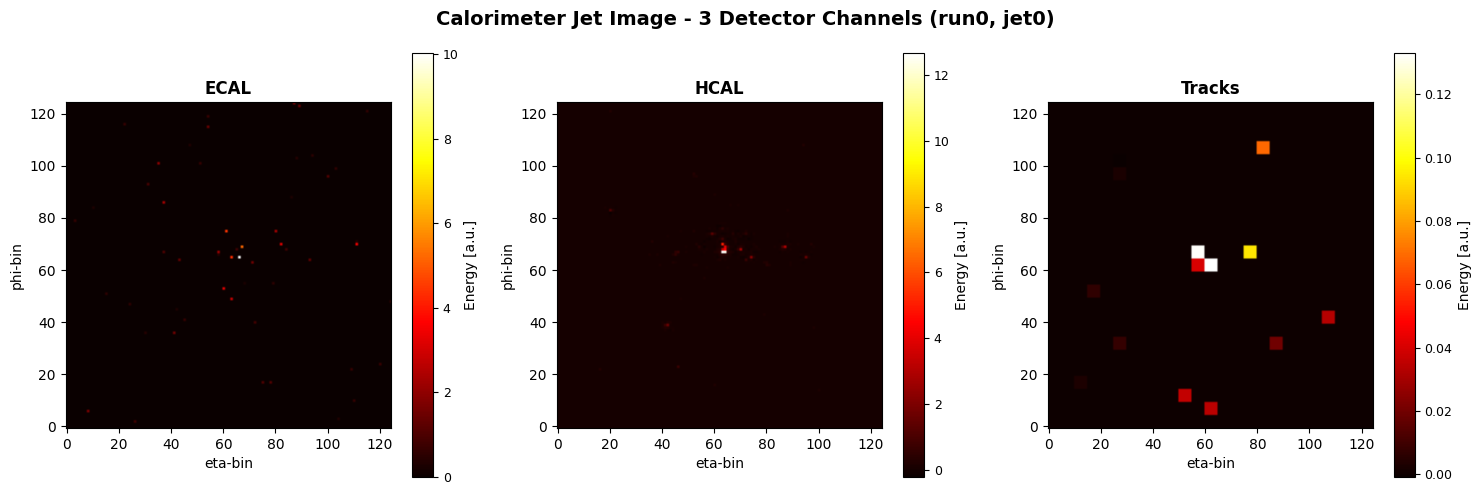

In [64]:
# Visualize 3-channel calorimeter heatmaps
ch_labels = ['ECAL', 'HCAL', 'Tracks']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Calorimeter Jet Image - 3 Detector Channels (run0, jet0)', fontweight='bold', fontsize=14)

for ch, (ax, name) in enumerate(zip(axes, ch_labels)):
    im = ax.imshow(jet[ch], cmap='hot', origin='lower', aspect='equal')
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_xlabel('eta-bin', fontsize=10)
    ax.set_ylabel('phi-bin', fontsize=10)
    cbar = plt.colorbar(im, ax=ax, label='Energy [a.u.]')
    cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

## 5. Energy Distribution Analysis

In [65]:
# Load and analyze energy distributions across all runs
ch_labels  = ['ECAL', 'HCAL', 'Tracks']
run_colors = ['steelblue', 'orange', 'green']

def load_channel_energies(file_path):
    """Load per-channel energy distributions from parquet file."""
    energies = {c: [] for c in ch_labels}
    done = 0
    quality_issues = {'nan': 0, 'inf': 0, 'negative': 0}
    
    for batch in pq.ParquetFile(file_path).iter_batches(batch_size=BATCH_SIZE):
        if done >= SAMPLE_SIZE: 
            break
        df_b = batch.to_pandas().head(SAMPLE_SIZE - done)
        
        for val in df_b[image_col]:
            jt = extract_jet(val)  # (3, H, W)
            
            # Quality checks
            if np.any(np.isnan(jt)):
                quality_issues['nan'] += 1
            if np.any(np.isinf(jt)):
                quality_issues['inf'] += 1
            if np.any(jt < 0):
                quality_issues['negative'] += 1
            
            # Calculate per-channel energies
            for i, c in enumerate(ch_labels):
                energies[c].append(float(jt[i].sum()))
        
        done += len(df_b)
    
    return energies, quality_issues

print("LOADING ENERGY DISTRIBUTIONS")
print("-" * 70)

run_data = []
all_quality_issues = []

for i, f in enumerate(PARQUET_FILES):
    energies, issues = load_channel_energies(f)
    run_data.append(energies)
    all_quality_issues.append(issues)
    print(f"run{i}: {len(energies['ECAL'])} jets loaded")

# Quality summary
print("\nQuality issues:")
for i, issues in enumerate(all_quality_issues):
    total_issues = sum(issues.values())
    if total_issues > 0:
        print(f"  run{i}: {issues}")
    else:
        print(f"  run{i}: None")


LOADING ENERGY DISTRIBUTIONS
----------------------------------------------------------------------
run0: 100 jets loaded
run1: 100 jets loaded
run2: 100 jets loaded

Quality issues:
  run0: {'nan': 0, 'inf': 0, 'negative': 100}
  run1: {'nan': 0, 'inf': 0, 'negative': 100}
  run2: {'nan': 0, 'inf': 0, 'negative': 99}


## 6. Energy Statistics

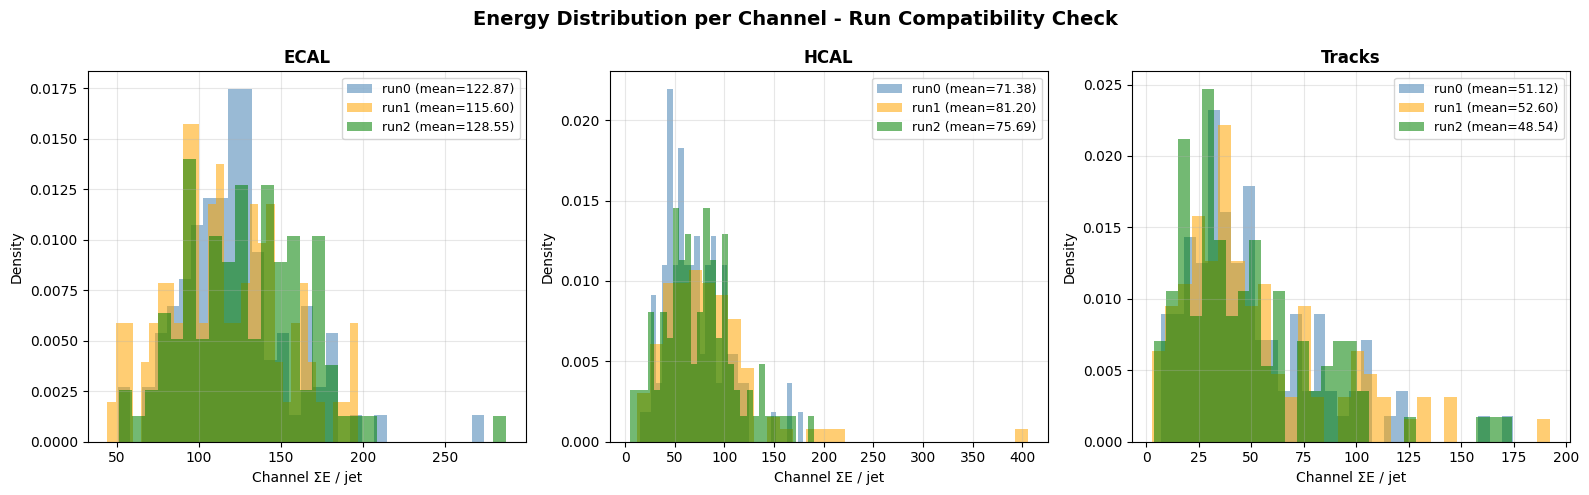


ENERGY STATISTICS
----------------------------------------------------------------------
ECAL:
  run0: mean=122.867  std= 33.770  range=[ 50.825, 273.987]
  run1: mean=115.600  std= 35.127  range=[ 44.489, 197.177]
  run2: mean=128.549  std= 37.192  range=[ 51.471, 287.134]
HCAL:
  run0: mean= 71.382  std= 31.176  range=[ 15.138, 179.211]
  run1: mean= 81.200  std= 50.079  range=[ 11.508, 405.602]
  run2: mean= 75.688  std= 37.487  range=[  4.521, 190.413]
Tracks:
  run0: mean= 51.115  std= 32.241  range=[  6.959, 174.784]
  run1: mean= 52.597  std= 36.113  range=[  2.641, 192.355]
  run2: mean= 48.535  std= 34.416  range=[  3.845, 173.964]


In [66]:
# Visualize energy distributions per channel across runs
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Energy Distribution per Channel - Run Compatibility Check', fontweight='bold', fontsize=14)

for ax, ch in zip(axes, ch_labels):
    for i, energies in enumerate(run_data):
        vals = energies[ch]
        ax.hist(vals, bins=30, alpha=0.55, density=True,
                color=run_colors[i], label=f'run{i} (mean={np.mean(vals):.2f})')
    ax.set_title(ch, fontweight='bold', fontsize=12)
    ax.set_xlabel('Channel ΣE / jet', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nENERGY STATISTICS")
print("-" * 70)
for ch in ch_labels:
    print(f"{ch}:")
    for i, d in enumerate(run_data):
        vals = d[ch]
        print(f"  run{i}: mean={np.mean(vals):7.3f}  std={np.std(vals):7.3f}  " +
              f"range=[{np.min(vals):7.3f}, {np.max(vals):7.3f}]")

## 7. Compatibility Testing

In [67]:
# Statistical tests for run compatibility
from scipy import stats

print("STATISTICAL COMPATIBILITY (Kolmogorov-Smirnov, alpha=0.05)")
print("-" * 70)

compatibility_results = []

for ch in ch_labels:
    print(f"\n{ch}:")
    
    # Pairwise KS tests
    for i in range(len(run_data)):
        for j in range(i+1, len(run_data)):
            sample1 = run_data[i][ch]
            sample2 = run_data[j][ch]
            
            # Kolmogorov-Smirnov test
            ks_stat, p_value = stats.ks_2samp(sample1, sample2)
            
            compatible = p_value > 0.05
            status = "PASS" if compatible else "FAIL"
            
            print(f"  run{i} vs run{j}: KS={ks_stat:.4f}, p-value={p_value:.4f}  [{status}]")
            
            compatibility_results.append({
                'channel': ch,
                'run1': i,
                'run2': j,
                'ks_stat': ks_stat,
                'p_value': p_value,
                'compatible': compatible
            })

# Summary
n_tests = len(compatibility_results)
n_compatible = sum(1 for r in compatibility_results if r['compatible'])
print(f"\nCompatibility: {n_compatible}/{n_tests} passed ({100*n_compatible/n_tests:.1f}%)")

STATISTICAL COMPATIBILITY (Kolmogorov-Smirnov, alpha=0.05)
----------------------------------------------------------------------

ECAL:
  run0 vs run1: KS=0.1800, p-value=0.0782  [PASS]
  run0 vs run2: KS=0.1900, p-value=0.0539  [PASS]
  run1 vs run2: KS=0.1700, p-value=0.1112  [PASS]

HCAL:
  run0 vs run1: KS=0.1300, p-value=0.3682  [PASS]
  run0 vs run2: KS=0.1100, p-value=0.5830  [PASS]
  run1 vs run2: KS=0.0800, p-value=0.9084  [PASS]

Tracks:
  run0 vs run1: KS=0.0600, p-value=0.9942  [PASS]
  run0 vs run2: KS=0.1300, p-value=0.3682  [PASS]
  run1 vs run2: KS=0.1200, p-value=0.4695  [PASS]

Compatibility: 9/9 passed (100.0%)


## 8. Summary

In [ ]:
# Validation summary
print("\nVALIDATION SUMMARY")
print("-" * 70)

print(f"Files: {len(PARQUET_FILES)}")
print(f"Sample size: {SAMPLE_SIZE} jets/file ({SAMPLE_SIZE * len(PARQUET_FILES)} total)")
print(f"Image shape: {n_ch} x {n_px} x {n_px}")
print(f"Channels: {', '.join(ch_labels)}")

# Quality metrics
total_quality_issues = sum(sum(issues.values()) for issues in all_quality_issues)
print(f"\nQuality issues: {total_quality_issues}")

# Statistical compatibility
compatibility_rate = n_compatible / n_tests * 100
print(f"Compatibility: {n_compatible}/{n_tests} tests passed ({compatibility_rate:.1f}%)")

# Energy statistics
print("\nEnergy ranges (sum per jet):")
for ch in ch_labels:
    all_energies = []
    for d in run_data:
        all_energies.extend(d[ch])
    print(f"  {ch:8s}: [{np.min(all_energies):7.3f}, {np.max(all_energies):7.3f}]  " +
          f"mean={np.mean(all_energies):.3f}  std={np.std(all_energies):.3f}")




VALIDATION SUMMARY
----------------------------------------------------------------------
Files: 3
Sample size: 100 jets/file (300 total)
Image shape: 3 x 125 x 125
Channels: ECAL, HCAL, Tracks

Quality issues: 299
Compatibility: 9/9 tests passed (100.0%)

Energy ranges (sum per jet):
  ECAL    : [ 44.489, 287.134]  mean=122.339  std=35.785
  HCAL    : [  4.521, 405.602]  mean=76.090  std=40.553
  Tracks  : [  2.641, 192.355]  mean=50.749  std=34.334

Completed: 2026-02-21 16:27:38
